#  Phân biệt các Thuật ngữ Khoa học dữ liệu, phân tích dữ liệu và kỹ sư dữ liệu

**Bối cảnh chung**: Hiện tại đang có:
- 2 file dữ liệu Orders khác nhau
- 1 file Product
- 1 file Customer

**Mục tiêu cuối cùng**:
Tạo ra 1 dataset Orders duy nhất, sạch, chuẩn hoá, có thể join chính xác với Product và Customer, phục vụ phân tích và mô hình ML.

## 1. Data Engineering
#### Nhiệm vụ: Thu thập và chuẩn hóa dữ liệu từ các nguồn khác nhau thành một "Single Source of Truth".

In [107]:
import pandas as pd
import numpy as np

### 1.1 Data preprocessing: Orders

In [108]:
df_orders_Q1 = pd.read_csv('lab03_Orders_Q1.csv')

In [ ]:
df_orders_Q1.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,""""""
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,""""""
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN


In [110]:
df_orders_Q1.info()

<class 'pandas.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         281 non-null    str    
 1   Order_Date       281 non-null    str    
 2   Order_Priority   281 non-null    str    
 3   Customer_ID      281 non-null    str    
 4   Industry_name    281 non-null    str    
 5   Province         279 non-null    str    
 6   Region           279 non-null    str    
 7   Channel          279 non-null    str    
 8   Product_ID       279 non-null    str    
 9   Sales            279 non-null    float64
 10  Quantity         279 non-null    float64
 11  Unit_Price       275 non-null    float64
 12  Discount         259 non-null    float64
 13  Profit           279 non-null    float64
 14  Returned_Reason  10 non-null     str    
dtypes: float64(5), str(10)
memory usage: 33.1 KB


In [111]:
df_orders_Q2 = pd.read_csv('lab03_Orders_Q2.csv')

In [ ]:
df_orders_Q2.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes
0,ĐN-2011-107181,5/12/24,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN,NaN
1,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN,NaN
2,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN,NaN
3,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN,NaN
4,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN,NaN


In [113]:
df_orders_Q1.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Unit_Price', 'Discount', 'Profit', 'Returned_Reason'],
      dtype='str')

In [114]:
df_orders_Q2.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Price', 'Discount', 'Profit', 'Returned_Reason', 'Notes'],
      dtype='str')

**Nhận xét**: df_orders_Q1 và df_orders_Q2
- có số lượng cols khác nhau
- Có 1 số cột khác nhau
==> Xử lý:
- Đồng nhất tên các cột có cùng ý nghĩa nhưng khác tên
- Chọn ra các cols có ý nghĩa hoặc cần sử dụng

In [ ]:
# Rename Price thành Unit_Price
df_orders_Q2 = df_orders_Q2.rename(columns={'Price':"Unit_Price"})

In [116]:
df_orders_Q2.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Notes
0,ĐN-2011-107181,5/12/24,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN,NaN
1,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN,NaN
2,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN,NaN
3,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN,NaN
4,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN,NaN


In [117]:
cols = df_orders_Q1.columns.to_list()

In [118]:
cols

['Order_ID',
 'Order_Date',
 'Order_Priority',
 'Customer_ID',
 'Industry_name',
 'Province',
 'Region',
 'Channel',
 'Product_ID',
 'Sales',
 'Quantity',
 'Unit_Price',
 'Discount',
 'Profit',
 'Returned_Reason']

In [119]:
df_orders_Q2 = df_orders_Q2[cols]

In [120]:
df_orders_Q2

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,ĐN-2011-107181,5/12/24,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN
1,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN
2,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN
3,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN
4,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,HT-2011-127166,5/21/24,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN
218,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN
219,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN
220,HC-2011-130673,5/20/24,Low,MC-17590,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-ST-10000636,66.960,5.0,13.392,0.2,-13.3920,NaN


In [ ]:
# union 2 files
df_orders = pd.concat([df_orders_Q1, df_orders_Q2], ignore_index=True)
df_orders.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,""""""
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,""""""
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN


### 1.2 Data preprocessing: Customers

In [122]:
df_cus = pd.read_csv('lab03_CUS.csv')

In [123]:
df_cus.head()

,Customer_ID,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,DP-13000,Darren Tran,Consumer,1/11/70,909123123,Vĩnh Long
1,PO-19195,Phillina Ober,Home Office,9/14/84,909123124,TP HCM
2,MB-18085,Trần Nhiễm,Consumer,1/11/96,909123127,Bình Dương
3,LS-17230,Lycoris Saunders,Consumer,1/11/82,909123128,Vĩnh Phúc
4,JO-15145,Jack O'Briant,Corporate,1/11/80,909123129,Bình Dương


### 1.3. Join 2 df: Orders & Customers

### 1.3.1 Join 2 df với cùng tên cột join

In [124]:
df_orders_cus = df_orders.merge(df_cus, on="Customer_ID", how="inner")

In [125]:
df_orders_cus

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1/11/70,909123123,Vĩnh Long
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,"""""",Phillina Ober,Home Office,9/14/84,909123124,TP HCM
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,"""""",Phillina Ober,Home Office,9/14/84,909123124,TP HCM
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN,Phillina Ober,Home Office,9/14/84,909123124,TP HCM
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1/11/96,909123127,Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,HT-2011-127166,5/21/24,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN,Trần Đức,Consumer,1/11/87,909123536,Hà Nội
498,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN,Trần Đức,Consumer,1/11/87,909123536,Hà Nội
499,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN,Trần Đức,Consumer,1/11/87,909123536,Hà Nội
500,HC-2011-130673,5/20/24,Low,MC-17590,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-ST-10000636,66.960,5.0,13.392,0.2,-13.3920,NaN,Nguyễn Thị Thu Hường,Corporate,1/11/79,909123609,Hà Tỉnh


In [126]:
df_orders_cus = df_orders.merge(df_cus, on="Customer_ID", how="left")

In [127]:
df_orders_cus

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1/11/70,909123123.0,Vĩnh Long
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN,Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1/11/96,909123127.0,Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,HT-2011-127166,5/21/24,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN,Trần Đức,Consumer,1/11/87,909123536.0,Hà Nội
499,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN,Trần Đức,Consumer,1/11/87,909123536.0,Hà Nội
500,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN,Trần Đức,Consumer,1/11/87,909123536.0,Hà Nội
501,HC-2011-130673,5/20/24,Low,MC-17590,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-ST-10000636,66.960,5.0,13.392,0.2,-13.3920,NaN,Nguyễn Thị Thu Hường,Corporate,1/11/79,909123609.0,Hà Tỉnh


### 1.3.2 Join 2 df với cùng khác tên cột join

In [128]:
df_orders_cus_1 = df_orders.merge(df_cus, left_on="Customer_ID", right_on="Customer_ID", how="left")
df_orders_cus_1.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1/11/70,909123123.0,Vĩnh Long
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN,Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1/11/96,909123127.0,Bình Dương


### 1.4. Data preprocessing: Product

In [129]:
df_prod = pd.read_csv('lab03_Product.csv')

### 1.5. Join 2 df: Orders_Customers with Product

In [130]:
df_final = df_orders_cus_1.merge(df_prod, on="Product_ID", how="left")

### 1.6. Các bước thực hiện:


*   Lần lượt đọc và xử lý các file riêng lẻ
*   Merge or Union các file lại với nhau để lấy đầy đủ thông tin
*   File sau khi đã được gom lại, tiến hành xử lý và kiểm tra



#### Yêu cầu:


*   B1: Đọc và tiền xử lý các file Lab03_Orders_Q1 và Lab03_Orders_Q2. Union 2 file này lại với nhau.
*   B2: Đọc và tiền xử lý các file Lab03_Cus
*   B3: Đọc và tiền xử lý các file Lab03_Product
*   B4: Join file Orders ở B1 với file Cus ở B2
*   B5: Join file Orders_Cus ở B4 với file Product ở B3



## 2. Data Analytics

Dữ liệu sử dụng:

Bảng: Orders_clean (các cột đã cung cấp)
Bảng tham chiếu: customer_info, product_info

Mục tiêu cuối cùng:
Dùng trực quan hóa để tìm ra xu hướng, mẫu hình, bất thường và trả lời câu hỏi:“Điều gì đã xảy ra trong hoạt động kinh doanh?”

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

### Task 1 — Phân tích xu hướng theo thời gian
Vẽ biểu đồ:

- Sales theo tháng/năm

- Profit theo tháng/năm

- Số lượng Orders theo thời gian

Câu hỏi cần trả lời:

- Doanh thu tăng hay giảm theo thời gian?

- Có yếu tố mùa vụ không?

In [132]:
df_orders.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,""""""
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,""""""
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN


In [133]:
df_orders['Order_Date'] = pd.to_datetime(df_orders['Order_Date'], errors='coerce')
df_orders['Month'] = df_orders['Order_Date'].dt.month
df_analysis = df_orders.dropna(subset=['Month'])

C:\Users\Khang\AppData\Local\Temp\ipykernel_10232\1415064868.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_orders['Order_Date'] = pd.to_datetime(df_orders['Order_Date'], errors='coerce')


In [134]:
monthly_data = df_analysis.groupby('Month').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()
# Đổi tên cột cho rõ nghĩa
monthly_data.rename(columns={'Order_ID': 'Order_Count'}, inplace=True)

In [135]:
monthly_data.head()

,Month,Sales,Profit,Order_Count
0,1.0,13162.269,2446.7711,78
1,2.0,4189.542,836.7144,46
2,3.0,54850.183,544.3635,154
3,4.0,28295.345,3488.8352,135
4,5.0,16546.966,1760.9807,88


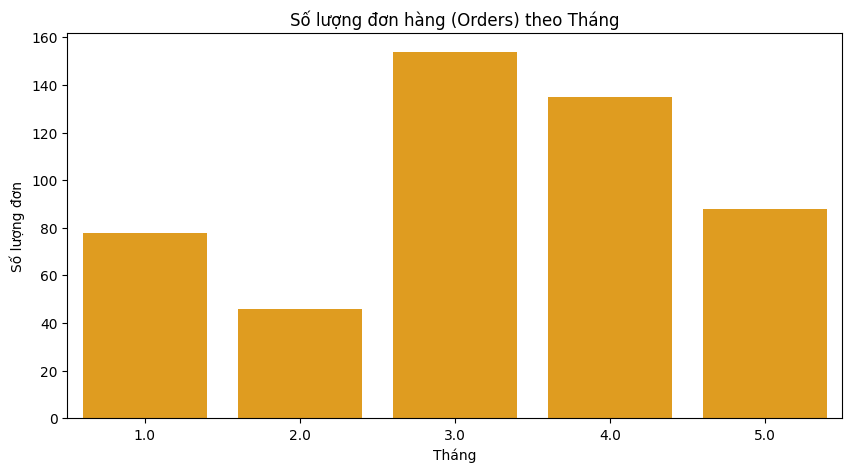

In [137]:
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_data, x='Month', y='Order_Count', color='orange')
plt.title('Số lượng đơn hàng (Orders) theo Tháng')
plt.xlabel('Tháng')
plt.ylabel('Số lượng đơn')
plt.show()

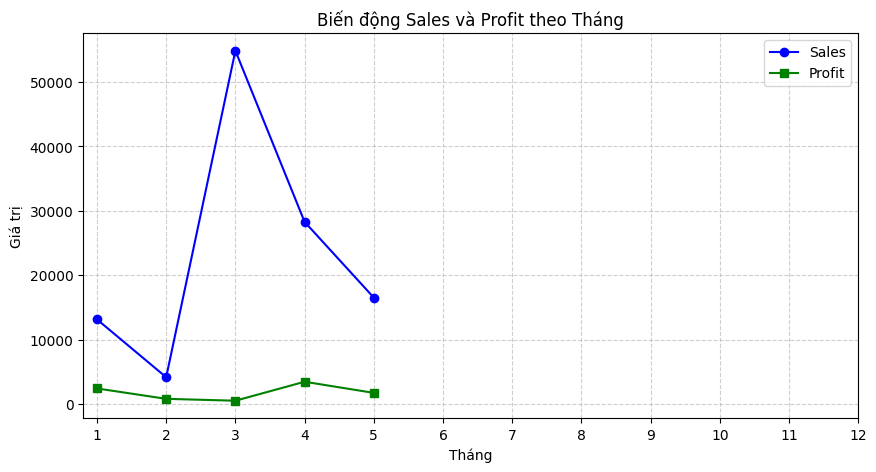

In [138]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_data['Month'], monthly_data['Sales'], marker='o', label='Sales', color='blue')
plt.plot(monthly_data['Month'], monthly_data['Profit'], marker='s', label='Profit', color='green')

plt.title('Biến động Sales và Profit theo Tháng')
plt.xlabel('Tháng')
plt.ylabel('Giá trị')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Task 2 — Phân tích theo khu vực (Region/Province)
Sales/Profit theo Region
Top Province theo Sales
So sánh Profit margin giữa các Region

Câu hỏi:

Khu vực nào bán nhiều nhưng lợi nhuận thấp?

In [139]:
# Gom nhóm theo Region
region_analysis = df_orders.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Tính Profit Margin (%)
region_analysis['Profit_Margin'] = (region_analysis['Profit'] / region_analysis['Sales']) * 100

# Sắp xếp theo Sales để xem nơi nào bán nhiều nhất
region_analysis = region_analysis.sort_values(by='Sales', ascending=False)

In [141]:
region_analysis.head()

,Region,Sales,Profit,Profit_Margin
4,Miền Trung,45450.347,1909.3227,4.200898
6,Miền Đông Nam Bộ,41924.634,4578.7161,10.921302
3,Miền Bắc,18558.067,1064.7224,5.737248
5,Miền Tây Nam Bộ,10386.503,1392.8505,13.410197
0,"""""",344.160,32.6344,9.482334


C:\Users\Khang\AppData\Local\Temp\ipykernel_10232\3090370662.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_analysis, x='Region', y='Sales', ax=ax1, palette='Blues_d')


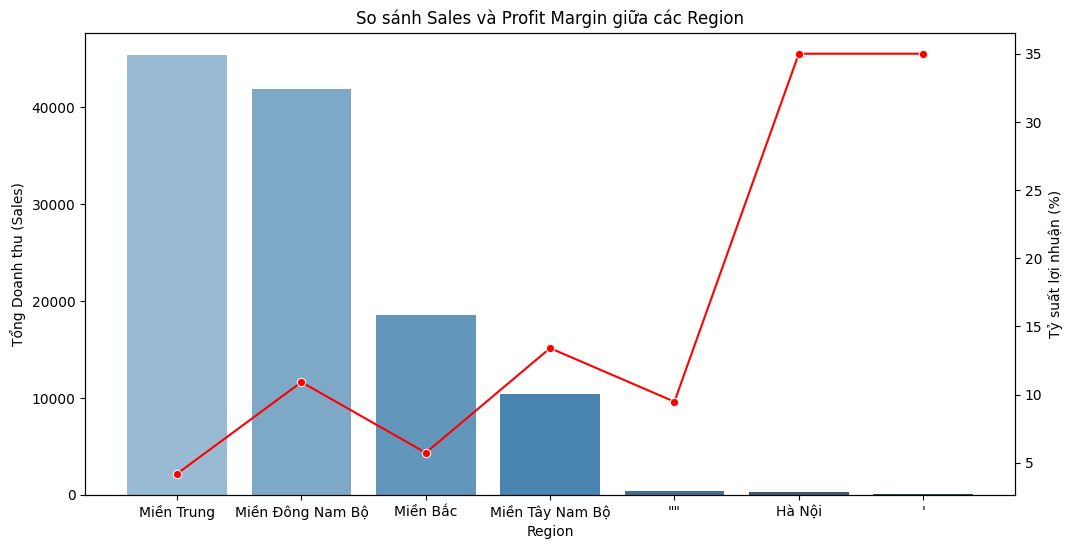

In [140]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Vẽ cột Sales
sns.barplot(data=region_analysis, x='Region', y='Sales', ax=ax1, palette='Blues_d')
ax1.set_ylabel('Tổng Doanh thu (Sales)')

# Tạo trục thứ 2 để vẽ đường Profit Margin
ax2 = ax1.twinx()
sns.lineplot(data=region_analysis, x='Region', y='Profit_Margin', marker='o', color='red', ax=ax2)
ax2.set_ylabel('Tỷ suất lợi nhuận (%)')

plt.title('So sánh Sales và Profit Margin giữa các Region')
plt.show()

### Task 3 — Phân tích theo Customer
Vẽ:

Sales theo Industry_name
Top khách hàng theo doanh thu (Pareto 80/20)
Industry vs Region (heatmap)

Câu hỏi:

Nhóm khách hàng chính là ai?

### Task 4 — Phân tích Returned_Reason

Vẽ:

- Tỷ lệ Returned theo Product / Region / Channel
- Phân bố Returned_Reason

Câu hỏi:

- Trả hàng tập trung ở đâu? Vì sao?

### Task 5 ( Optional): Xây dựng Dashboard
Dashboard cần có:

- KPI: Total Sales, Profit, Orders, Return Rate
- Bộ lọc: Thời gian, Region, Channel, Industry, Product
- Lựa chọn một số biểu đồ chính thể hiện lên dashboard

## 3. Data scientist

**Mục tiêu**:
Xây dựng một mô hình Regression để dự đoán Profit của đơn hàng dựa trên dữ liệu đã làm sạch.

Dữ liệu sử dụng:

Orders_clean (đã join với customer_info, product_info)

Biến mục tiêu (target): Profit

Task 1 — Chuẩn bị dữ liệu cho mô hình
- Chọn các biến đầu vào phù hợp
- Xử lý dữ liệu
  + Encode biến phân loại (categorical)
  + Chuẩn hoá dữ liệu số (nếu cần)
  + Loại bỏ missing / outlier nghiêm trọng

Task 2 — Chia tập train/test

Task 3 — Huấn luyện mô hình Regression cơ bản: Linear Regression

Task 4 — Đánh giá mô hình
Sử dụng các metric:
- MAE
- RMSE
- R²

Task 5 — Phân tích Feature Importance

- Xác định biến nào ảnh hưởng nhiều nhất đến Profit

- Giải thích ngắn gọn kết quả

## 4. Homework

Yêu cầu: Sinh viên thực hiện bài tập với ba vai trò như sau:

- Vai trò Data Engineer: Xử lý các file dữ liệu đầu vào, chuẩn hoá và làm sạch dữ liệu, sau đó tạo ra một file dữ liệu sạch dùng chung.
- Vai trò Data Analyst: Sử dụng tập dữ liệu sạch bởi data engineer, hãy trực quan hoá dữ liệu bằng các biểu đồ, khám phá dữ liệu và trả lời các câu hỏi đã nêu ở Mục 2. Data Analytics.
- Vai trò Data Scientist: Xây dựng mô hình regression để dự đoán Profit và đưa ra nhận xét về kết quả.


Yêu cầu nộp bài: Nộp file .ipynb với cú pháp: MSSV_Hoten_HW1.ipynb
- Hoten: viết liền không dấu
- Trong file, tạo 1 text: ghi rõ thông tin của sinh viên:
   + MSSV:
   + Họ tên: viết tên đầy đủ có dấu
Lưu ý: Cần nộp định dạng file .ipynb